# Ejercicio 07 · Evaluación de impacto y auditoría de equidad

Marlenis Judith Concepción Cuevas · INF-8239-C2 · Unidad IV

Integra LAB11 (evaluación de impacto) y LAB12 (auditoría con Fairlearn) sobre el proyecto base `INF8239_U04_Gobernanza_DSS_Proyecto_Base_uv`. Datos sintéticos.

In [1]:
import json, os, subprocess, sys
from pathlib import Path
import pandas as pd, yaml
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
os.chdir(ROOT)
subprocess.run([sys.executable, "scripts/run_e07.py"], check=True, capture_output=True)
pd.set_option("display.max_colwidth", 90)

## 1. Finalidad e interesados (LAB11)

In [2]:
display(pd.Series(yaml.safe_load(Path("student_inputs/lab11_impact.yml").read_text())).to_frame("contenido"))
pd.read_csv("student_inputs/stakeholders.csv")

,contenido
purpose,Ordenar los casos territoriales entrantes para que el equipo técnico revise primero lo...
assisted_decision,Orden de revisión humana de casos (qué caso mira primero el analista). La intervención...
users,Analistas territoriales que revisan casos y su supervisor de turno.
affected_population,"Personas y comunidades de las zonas Norte, Sur, Este y Oeste cuyos casos se registran;..."
owner,Responsable institucional del programa territorial (Product Owner); responde por la de...
non_predictive_alternative,"Regla transparente sin modelo, priorizar si hay 4 o más incidentes previos o exposició..."
out_of_scope_use,"Decidir automáticamente intervenciones, elegibilidad para ayudas o declaratorias de em..."
withdrawal_condition,"Retirar o volver a la regla transparente si el recall baja de 0.68, si la brecha de re..."
appeal_mechanism,Cualquier persona u organización comunitaria puede pedir revisión manual de la priorid...


,stakeholder,benefit,harm,power,participation
0,Affected person,Su caso de alto riesgo se revisa antes,Quedar al final de la cola por un falso negativo o ser revisado sin necesidad por un f...,low,Canal de apelación y consulta comunitaria antes del piloto
1,Operator,Ordena la carga de trabajo con un criterio explícito,Sobrecarga si hay muchos falsos positivos; exceso de confianza en la lista (sesgo de a...,medium,Capacitación y registro de discrepancias con la lista sugerida
2,Institutional owner,Usa mejor el tiempo del equipo y documenta decisiones,Responsabilidad legal y reputacional si el sistema discrimina,high,Aprueba o retira el sistema y firma el registro de decisión
3,Data team,Mejora el sistema con evidencia y retroalimentación,Culpa por errores de datos o de modelo fuera de su control,medium,Mantiene auditorías y monitoreo; propone cambios
4,Community organizations,Transparencia sobre cómo se prioriza su zona,Estigmatización de zonas o grupos,low,Reciben el resumen de auditoría y pueden observar el piloto


## 2. Registro de riesgos priorizado y NIST AI RMF

In [3]:
pd.read_csv("reports/lab11/risk_register_scored.csv")[["id", "scenario", "priority", "owner", "rmf_subcategory"]]

,id,scenario,priority,owner,rmf_subcategory
0,R01,Casos de alto riesgo del grupo G1 quedan al final de la cola (recall 0.65 frente a 0.7...,12,Data Scientist,MEASURE 2.11
1,R02,Conclusiones sobre subgrupos pequeños (G2 45-59 tiene 8 casos en prueba) presentadas c...,9,Data Scientist,MAP 2.3
2,R07,Sesgo de automatización: el analista sigue la lista sin revisar,9,Institutional Owner,MAP 3.4
3,R03,Uso del sistema para decidir intervenciones o elegibilidad en lugar de ordenar revisiones,8,Institutional Owner,MAP 1.1
4,R04,Uso del grupo protegido o la edad como criterio de decisión (tratamiento diferenciado),8,Data Scientist,GOVERN 1.1
5,R08,Degradación o cambio de población después del despliegue,6,ML Engineer,MANAGE 4.1
6,R06,Sobrecarga del equipo por falsos positivos de la regla (FPR 0.37),6,Product Owner,MEASURE 2.8
7,R05,Filtración de identificadores directos al conjunto de datos,4,Data Engineer,MEASURE 2.10


## 3. Obligación legal, marco voluntario y recomendación ética

In [4]:
display(Markdown(Path("docs/MARCO_NORMATIVO.md").read_text().split("## Proporcionalidad")[0]))

# Marco normativo · obligación legal, marco voluntario y recomendación ética

Análisis académico; no sustituye asesoría jurídica. Los datos del proyecto son sintéticos y no contienen personas reales, así que las obligaciones legales se aplicarían si el sistema se usara con datos reales en República Dominicana.

| Tipo | Fuente | Qué exige o recomienda | Cómo se aplica aquí | Evidencia |
|---|---|---|---|---|
| **Obligación legal** | Ley No. 172-13 sobre protección de datos personales (13 de diciembre de 2013; Gaceta Oficial No. 10737) | Protección integral de los datos personales en archivos, registros y bancos de datos, públicos o privados | Con datos reales: base legal para el tratamiento, finalidad declarada y datos mínimos. El esquema rechaza identificadores directos | `configs/governance.yml`, `tests/test_privacy.py` |
| **Obligación legal** | Constitución de la República Dominicana, art. 44 (intimidad y honor) | Respeto y no injerencia en la vida privada | No se usan ni guardan identificadores; el sistema no perfila personas | `src/inf8239_u04/data.py` |
| **Obligación legal** | Constitución, art. 70 (hábeas data) | Derecho a conocer, rectificar y exigir la supresión de datos propios, incluso en caso de discriminación | Mecanismo de apelación y revisión manual documentado | `student_inputs/lab11_impact.yml` |
| **Obligación legal** | Constitución, art. 39 (igualdad) | Igualdad y no discriminación | El grupo protegido no se usa para decidir; se audita la brecha por grupo | `reports/lab12/` |
| **Marco voluntario** | NIST AI Risk Management Framework 1.0 (NIST AI 100-1, 2023) | Funciones GOVERN, MAP, MEASURE y MANAGE | Cada riesgo del registro se vincula a una subcategoría (GOVERN 1.1, MAP 1.1, MAP 2.3, MAP 3.4, MEASURE 2.8, 2.10, 2.11 y MANAGE 4.1) | `student_inputs/risk_register.csv` |
| **Marco voluntario** | Mitchell et al. (2019), *Model Cards*; Gebru et al. (2021), *Datasheets for Datasets* | Documentar uso previsto, datos, métricas por grupo y límites | Dataset Card y Model Card (se completan en el Ejercicio 08) | `docs/` |
| **Recomendación ética** | Decisión propia del análisis | Preferir la alternativa menos intrusiva y explicable cuando rinde igual | Se elige la regla transparente en lugar del modelo | `reports/lab12/decision.json` |
| **Recomendación ética** | Decisión propia del análisis | No decidir sobre subgrupos con menos de 30 casos | Se marcan las celdas pequeñas y se limita el uso a un piloto | `reports/lab12/interseccional.csv` |
| **Recomendación ética** | Decisión propia del análisis | Supervisión humana significativa y derecho a apelar | La lista solo ordena revisiones; decide una persona | `app.py`, `lab11_impact.yml` |



## 4. Auditoría (LAB12): candidatos, grupos e intersecciones

,etapa,candidato,accuracy,recall,fpr,selection_rate,recall_gap,fpr_gap,selection_gap
0,validacion,regla_no_predictiva,0.750,0.828,0.339,0.600,0.115,0.135,0.129
1,validacion,logistica_0.50,0.800,0.812,0.214,0.533,0.079,0.135,0.111
2,validacion,arbol_0.50,0.767,0.781,0.250,0.533,0.262,0.146,0.213
3,validacion,logistica_0.56,0.808,0.812,0.196,0.525,0.079,0.094,0.092
4,validacion,threshold_optimizer_eo,0.767,0.750,0.214,0.500,0.127,0.010,0.068
5,prueba,regla_no_predictiva,0.700,0.750,0.368,0.588,0.011,0.010,0.090
6,prueba,logistica_0.50,0.719,0.717,0.279,0.531,0.138,0.125,0.232
7,prueba,arbol_0.50,0.706,0.717,0.309,0.544,0.181,0.168,0.266
8,prueba,logistica_0.56,0.744,0.696,0.191,0.481,0.135,0.077,0.231
9,prueba,threshold_optimizer_eo,0.700,0.804,0.441,0.650,0.069,0.168,0.009


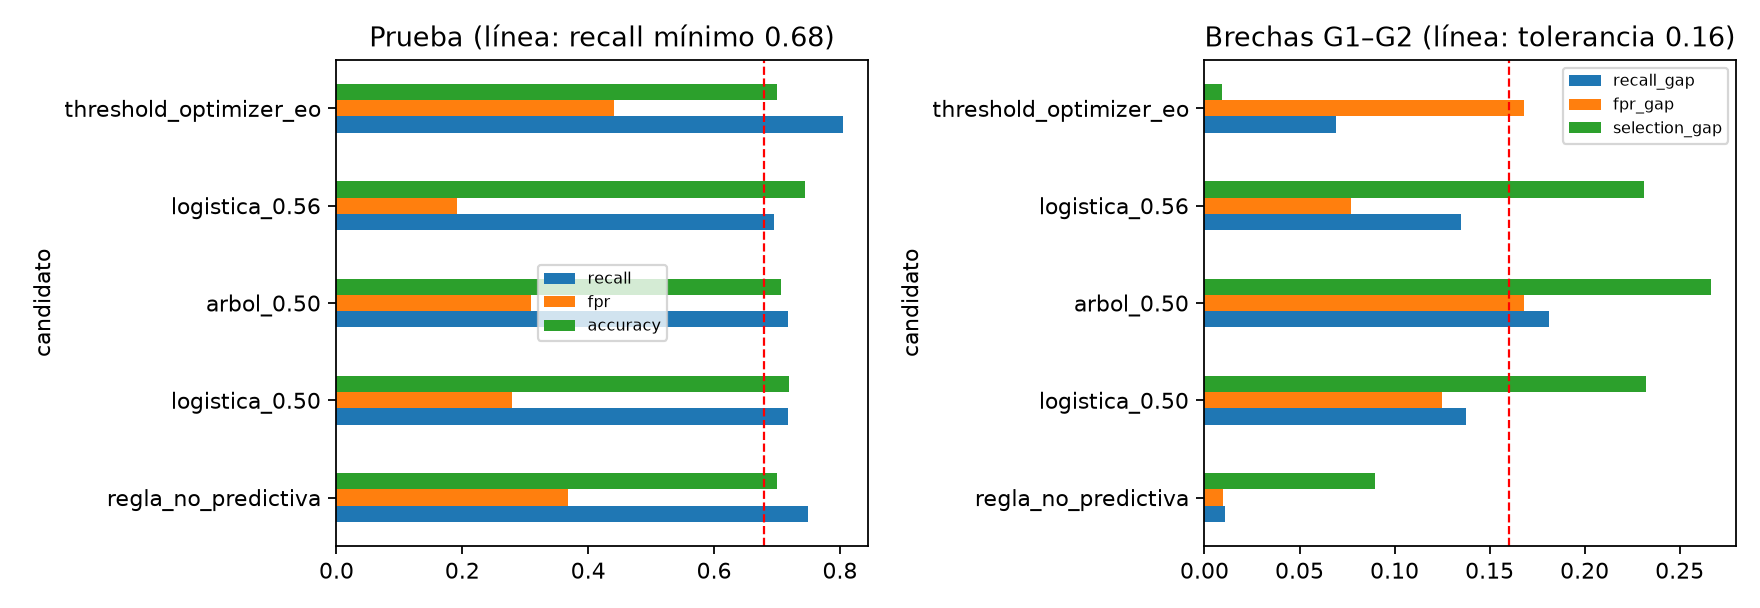

In [5]:
display(pd.read_csv("reports/lab12/candidatos.csv").round(3))
Image(filename="reports/lab12/candidatos.png")

In [6]:
display(pd.read_csv("reports/lab12/por_grupo.csv", index_col=0).round(3))
display(pd.read_csv("reports/lab12/por_edad.csv", index_col=0).round(3))
pd.read_csv("reports/lab12/interseccional.csv", index_col=0).round(3)

,count,accuracy,selection_rate,recall,precision,fpr
sensitive_feature_0,,,,,,
G1,101.0,0.693,0.554,0.755,0.661,0.365
G2,59.0,0.712,0.644,0.744,0.842,0.375


,count,accuracy,selection_rate,recall,precision,fpr
age_band,,,,,,
18-29,29.0,0.621,0.655,0.833,0.526,0.529
30-44,38.0,0.737,0.632,0.750,0.875,0.300
45-59,43.0,0.744,0.512,0.739,0.773,0.250
60+,50.0,0.680,0.580,0.724,0.724,0.381


,count,accuracy,selection_rate,recall,precision,fpr,n_suficiente
sensitive_feature_0,,,,,,,
G1 | 18-29,18.0,0.556,0.556,0.750,0.300,0.500,False
G1 | 30-44,24.0,0.708,0.625,0.750,0.800,0.375,False
G1 | 45-59,35.0,0.714,0.486,0.706,0.706,0.278,True
G1 | 60+,24.0,0.750,0.583,0.833,0.714,0.333,False
G2 | 18-29,11.0,0.727,0.818,0.875,0.778,0.667,False
G2 | 30-44,14.0,0.786,0.643,0.750,1.000,0.000,False
G2 | 45-59,8.0,0.875,0.625,0.833,1.000,0.000,False
G2 | 60+,26.0,0.615,0.577,0.647,0.733,0.444,False


In [7]:
json.loads(Path('reports/lab12/bootstrap.json').read_text())

{'regla_no_predictiva': {'recall_gap': [0.0037037037037037646,
   0.20783790650406497],
  'fpr_gap': [0.004079234972677603, 0.3312306501547987]},
 'logistica_0.50': {'recall_gap': [0.010827498712249885, 0.3139834223498571],
  'fpr_gap': [0.00510160843998617, 0.3975362685931603]}}

## 5. Decisión

In [8]:
decision = json.loads(Path("reports/lab12/decision.json").read_text())
print(decision["decision"].upper())
decision

LIMITAR


{'candidato_elegido': 'regla_no_predictiva',
 'razon_eleccion': 'Cumplen las compuertas en validación: regla_no_predictiva, logistica_0.50, logistica_0.56. Se elige el de mayor recall: regla_no_predictiva. ThresholdOptimizer se excluye porque necesita el grupo protegido en el momento de decidir (tratamiento diferenciado explícito).',
 'umbral_global': 0.56,
 'recall_objetivo': 0.8,
 'train': 480,
 'valid': 120,
 'test': 160,
 'decision': 'limitar',
 'cumple_compuertas_en_prueba': True,
 'incertidumbre_supera_tolerancia': True,
 'celdas_interseccionales_pequenas': 7,
 'modelo_ml_logistica': {'decision': 'limitar',
  'cumple_compuertas_en_prueba': True,
  'incertidumbre_supera_tolerancia': True,
  'celdas_interseccionales_pequenas': 7},
 'tomada_con_validacion': True}

## 6. Interpretación

| | |
|---|---|
| **Observación** | La regla transparente alcanza recall 0.75 en prueba con brechas de 0.01; la regresión logística, 0.72 con brecha de recall de 0.14. |
| **Evidencia** | `candidatos.csv`; la regla tuvo el mayor recall en validación y se eligió antes de mirar la prueba. |
| **Interpretación** | Con 160 casos de prueba, el intervalo de la brecha llega a 0.21 y casi todas las celdas interseccionales tienen menos de 30 casos: no se puede asegurar que la brecha sea tolerable. |
| **Decisión** | **Limitar**: la regla transparente solo ordena revisiones humanas en un piloto con apelación y monitoreo; no se utiliza el modelo de aprendizaje automático. |